<xarray.Dataset> Size: 10kB
Dimensions:            (psi_n_1d: 111, species: 3)
Coordinates:
  * psi_n_1d           (psi_n_1d) float64 888B 0.0 0.001224 ... 0.9935 1.0
  * species            (species) object 24B 'T' 'D' 'LUMPED'
Data variables: (12/22)
    te                 (psi_n_1d) float64 888B ...
    ne                 (psi_n_1d) float64 888B ...
    ss_ion_temp        (psi_n_1d) float64 888B ...
    ss_ion_density     (psi_n_1d) float64 888B ...
    ni                 (species, psi_n_1d) float64 3kB ...
    ti                 (species, psi_n_1d) float64 3kB ...
    ...                 ...
    a                  float64 8B ...
    kappa              float64 8B ...
    delta              float64 8B ...
    up_down_symmetric  bool 1B ...
    Ip_target          float64 8B ...
    pax_target         float64 8B ...
Attributes:
    total_electron_density_m3:  5.858345726203842e+20
    total_ion_density_m3:       5.198980913200166e+20
    single_species_model:       1
GEQDSKFile(comment=

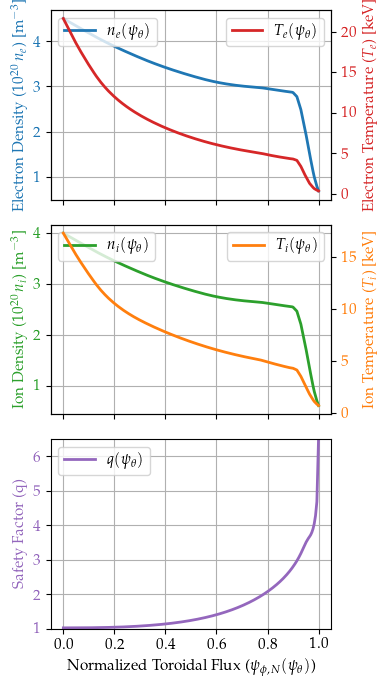

In [17]:
# Load in and plot Stuart kinetic profiles xarray
from freeqdsk import geqdsk
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
rc('font',**{'family':'serif','serif':['Palatino']})
rc('font',**{'size':11})
rc('text', usetex=True)
import numpy as np
from scipy.integrate import cumulative_trapezoid as cumtrapz
from freeqdsk import geqdsk

file_geqdsk = 'shftfac0.0neoTrueal1.56ga1.805_ipscl1.0_pscl1.0f0.05_ps0p136_alphaspike_qmin1p024.eqdsk'
file_kinetic = 'testKIN__FiniteBeta_profiles.nc'

# Load in the data
ds = xr.open_dataset(file_kinetic)

print(ds)
# Plot the profiles

with open(file_geqdsk,'r') as f: eqdsk=geqdsk.read(f)

print(eqdsk)

# Poloidal flux array from gEQDSK
psi_lin = np.linspace(eqdsk.simagx, eqdsk.sibdry, eqdsk.nx)

psi_norm = np.sqrt((psi_lin - eqdsk.simagx) / (eqdsk.sibdry - eqdsk.simagx))  # Normalized psi (0 to 1)

# Compute toroidal flux by integrating 1/q dpsi
psi_tor_vals = cumtrapz( eqdsk.qpsi, psi_lin, initial=0)

psi_tor_norm = np.sqrt(psi_tor_vals/psi_tor_vals[-1])  # Take square root to get psi_tor: on psi_pol linear vector


q = eqdsk.qpsi # q on psi_pol linear vector

# Need ne, te as a function of Psi_n, to then insert Psi_n as a function of Psi_pol,
# #  to get ne, te as a function of psi_pol linear vector. Then can plot against psi_pol linear vector.
# Get ne, te as a function of Psi_n
ne_Psi_n = ds['ne'].values
te_Psi_n = ds['te'].values
Psi_n = ds['psi_n_1d'].values

# Interpolate psi_norm as a function of psi_pol linear vector
from scipy.interpolate import interp1d
interp_psi_n = interp1d(psi_lin, psi_norm, bounds_error=False, fill_value="extrapolate")
psi_n_interp = interp_psi_n(Psi_n) # Interpolated Psi_n on psi_pol linear vector

# Interpolate ne, te as a function of psi_pol linear vector
interp_ne = interp1d(Psi_n, ne_Psi_n, bounds_error=False, fill_value="extrapolate")
interp_te = interp1d(Psi_n, te_Psi_n, bounds_error=False, fill_value="extrapolate")
interp_ss_ti = interp1d(Psi_n, ds['ss_ion_temp'].values, bounds_error=False, fill_value="extrapolate")
interp_ss_ni = interp1d(Psi_n, ds['ss_ion_density'].values, bounds_error=False, fill_value="extrapolate")

ne_psi_pol = interp_ne(psi_norm) # ne interpolated on psi_pol linear vector
te_psi_pol = interp_te(psi_norm) # te interpolated on psi_pol linear vector
ni_psi_pol = interp_ss_ni(psi_norm) # ion density interpolated on psi_pol linear vector
ti_psi_pol = interp_ss_ti(psi_norm) # ion temperature interpolated on psi_pol linear vector



# Save output: 
output_ds = xr.Dataset(
    {
        'psi_norm': (['psi_pol'], psi_norm),
        'psi_tor_norm': (['psi_pol'], psi_tor_norm),
        'q': (['psi_pol'], q),
        'ne_psi_pol': (['psi_pol'], ne_psi_pol),
        'te_psi_pol': (['psi_pol'], te_psi_pol),
        'ni_psi_pol': (['psi_pol'], ni_psi_pol),
        'ti_psi_pol': (['psi_pol'], ti_psi_pol)
    },
    coords={
        'psi_pol': psi_lin
    }
)

output_ds.to_netcdf('processed_profiles.nc')


# Plotting
fig, ax = plt.subplots(3,1,figsize=(4,7),tight_layout=True,sharex=True)
# ax[0].set_xlabel(r'Normalized Toroidal Flux ($\psi_\phi(\psi_\theta)$)')
ax[0].set_ylabel(r'Electron Density ($10^{20}\,n_e$) [m$^{-3}$]', color='tab:blue')
ax[0].plot(psi_tor_norm, ne_psi_pol*1e-20, label=r'$n_e(\psi_\theta)$', color='tab:blue')
ax[0].tick_params(axis='y', labelcolor='tab:blue')
ax[0].legend(loc='upper left')
ax[0].grid()

# Plot electron temperature on the same figure
ax2 = ax[0].twinx()
ax2.set_ylabel(r'Electron Temperature ($T_e$) [keV]', color='tab:red')
ax2.plot(psi_tor_norm, te_psi_pol, label=r'$T_e(\psi_\theta)$', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# ax[1].set_xlabel(r'Normalized Toroidal Flux ($\psi_{tor}$)')
ax[1].set_ylabel(r'Ion Density ($10^{20}\,n_i$) [m$^{-3}$]', color='tab:green')
ax[1].plot(psi_tor_norm, ni_psi_pol*1e-20, label=r'$n_i(\psi_\theta)$', color='tab:green')
ax[1].tick_params(axis='y', labelcolor='tab:green')
ax[1].legend(loc='upper left')
ax[1].grid()

# Plot ion temperature on the same figure
ax3 = ax[1].twinx()
ax3.set_ylabel(r'Ion Temperature ($T_i$) [keV]', color='tab:orange')
ax3.plot(psi_tor_norm, ti_psi_pol, label=r'$T_i(\psi_\theta)$', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')
ax3.legend(loc='upper right')
ax[2].set_xlabel(r'Normalized Toroidal Flux ($\psi_{\phi, N}(\psi_\theta)$)')
ax[2].set_ylabel('Safety Factor (q)', color='tab:purple')
ax[2].plot(psi_tor_norm, q, label=r'$q(\psi_\theta)$', color='tab:purple')
ax[2].tick_params(axis='y', labelcolor='tab:purple')
ax[2].legend(loc='upper left')
ax[2].set_ylim(1,6.5)
ax[2].grid()

plt.tight_layout()

fig.savefig('stuart_profiles.pdf', transparent=True)
plt.show()

In [2]:
print(len(psi_lin), len(eqdsk.qpsi), len(psi_tor_vals))

257 257 257


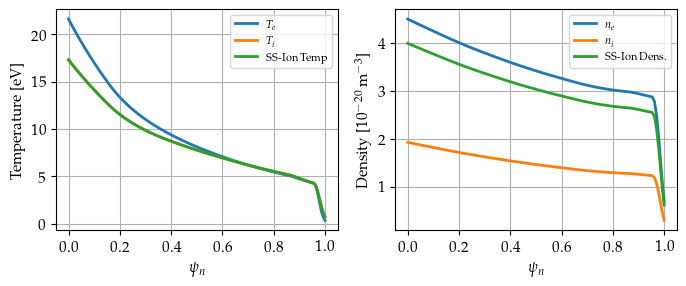

In [21]:
from matplotlib import rc
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
rc('font',**{'family':'serif','serif':['Palatino']})
rc('font',**{'size':11})
rc('text', usetex=True)
import matplotlib;

fig,ax = plt.subplots(1,2,figsize=(7,3),tight_layout=True)
ax[0].plot(ds['psi_n_1d'], ds['te'], label=r'$T_e$')
ax[0].plot(ds['psi_n_1d'], ds['ti'].sel(species='D'), label=r'$T_i$')
ax[0].plot(ds['psi_n_1d'], ds['ss_ion_temp'], label='SS-Ion Temp')

ax[1].plot(ds['psi_n_1d'], ds['ne']*1e-20, label='$n_e$')
ax[1].plot(ds['psi_n_1d'], ds['ni'].sel(species='T')*1e-20, label=r'$n_i$')
ax[1].plot(ds['psi_n_1d'], ds['ss_ion_density']*1e-20, label='SS-Ion Dens.')


ax[0].set_xlabel(r'$\psi_n$')
ax[0].set_ylabel('Temperature [eV]')
ax[0].grid()
ax[0].legend(fontsize=8)

ax[1].set_xlabel(r'$\psi_n$')
ax[1].set_ylabel(r'Density [$10^{-20}$ m$^{-3}$]')
ax[1].grid()
ax[1].legend(fontsize=8)

fig.savefig('../output_plots/Stuart_profiles.pdf',transparent=True)

In [ ]:
################ Open gEQDSK File ##################
from freeqdsk import geqdsk
file_geqdsk = 'shftfac0.0neoTrueal1.56ga1.805_ipscl1.0_pscl1.0f0.05_ps0p136_alphaspike_qmin1p024.eqdsk'

with open('../signal_generation/input_data/'+file_geqdsk,'r') as f: eqdsk=geqdsk.read(f)

print(eqdsk)

# Converting to Rho-Tor
# Poloidal flux array from gEQDSK
psi_lin = np.linspace(eqdsk.simagx, eqdsk.sibdry, eqdsk.nx)

psi_norm = np.sqrt((psi_lin - eqdsk.simagx) / (eqdsk.sibdry - eqdsk.simagx))  # Normalized psi (0 to 1)

# Compute toroidal flux by integrating 1/q dpsi
psi_tor_vals = cumtrapz(1 / eqdsk.qpsi, psi_lin, initial=0)

psi_tor_norm = np.sqrt(psi_tor_vals/psi_tor_vals[-1])  # Take square root to get psi_tor

GEQDSKFile(comment='tMaker:', shot=0, nx=257, ny=257, rdim=np.float64(1.27700555), zdim=np.float64(3.46499991), rcentr=np.float64(1.8533386), rleft=np.float64(1.21095431), zmid=np.float64(0.0), rmagx=np.float64(1.89316523), zmagx=np.float64(1.50388441e-05), simagx=np.float64(1.19224834), sibdry=np.float64(-0.920264781), bcentr=np.float64(12.1380949), cpasma=np.float64(8879731.0), fpol=array([23.3090439, 23.3054676, 23.3018837, 23.2982864, 23.2946548,
       23.290987 , 23.2872734, 23.2835064, 23.2796898, 23.2758274,
       23.2719173, 23.2679653, 23.2639732, 23.2599449, 23.2558804,
       23.2517834, 23.2476559, 23.2434978, 23.2393112, 23.235096 ,
       23.2308559, 23.2265911, 23.2223015, 23.217989 , 23.2136555,
       23.2092991, 23.2049217, 23.2005272, 23.1961136, 23.1916828,
       23.187233 , 23.1827679, 23.1782856, 23.1737881, 23.1692753,
       23.1647472, 23.1602058, 23.1556511, 23.151083 , 23.1465015,
       23.1419086, 23.137289 , 23.1326389, 23.1279488, 23.1232109,
       23